In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Dataset Head:
    Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 colu

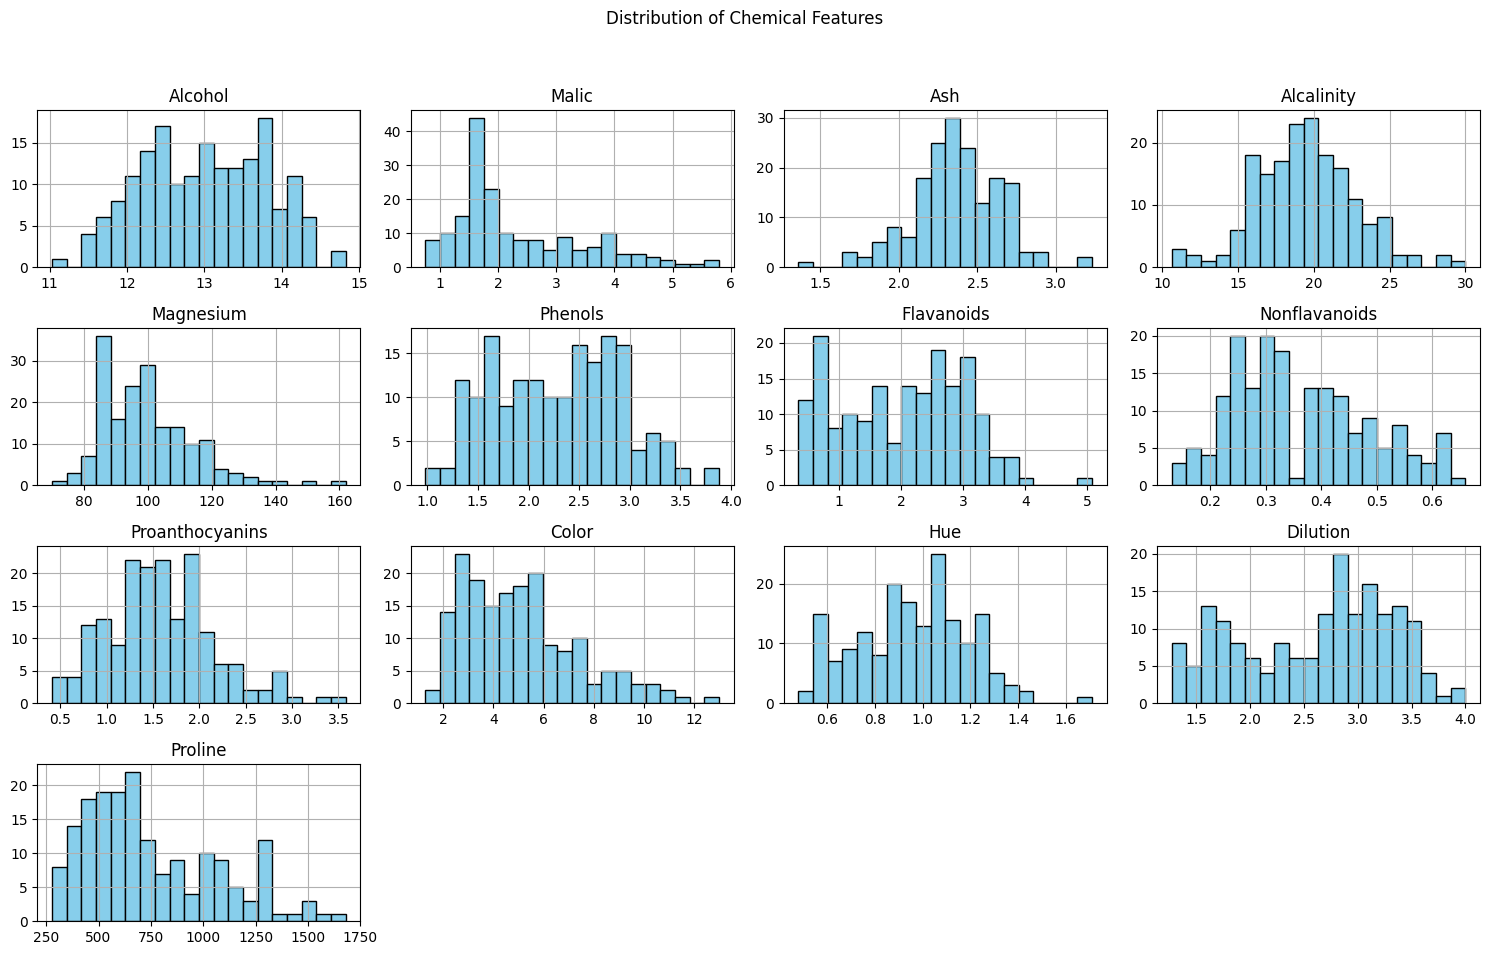

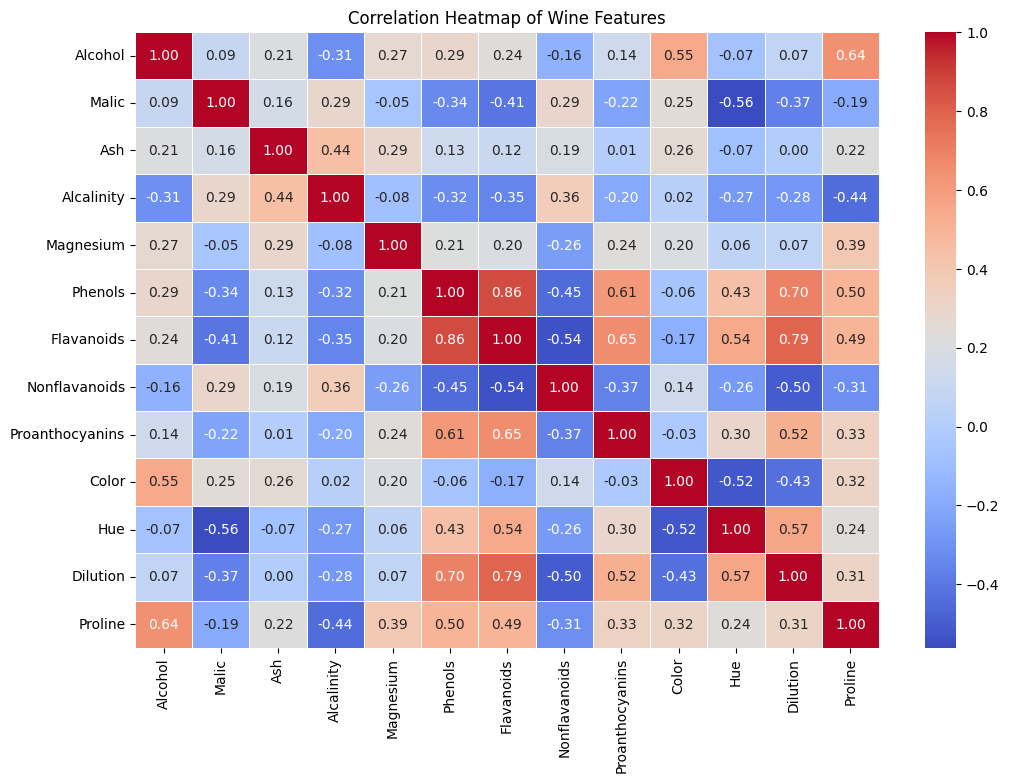

In [3]:
# ==========================================
# Task 1: Exploratory Data Analysis (EDA)
# ==========================================

# 1. Load the dataset
df = pd.read_csv('wine.csv')

# 2. Basic exploration
print("Dataset Head:\n", df.head())
print("\nDataset Info:")
df.info()

# 3. Examine distribution of features
# Dropping 'Type' as it is the target label
features = df.drop('Type', axis=1)

features.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Chemical Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('feature_distributions.png')

# 4. Investigate correlations
plt.figure(figsize=(12, 8))
sns.heatmap(features.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.savefig('correlation_heatmap.png')

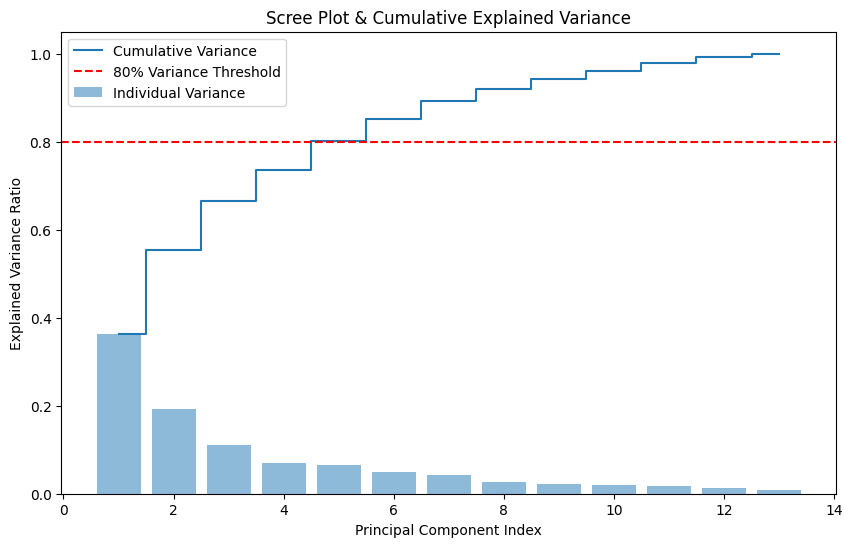

In [4]:

# ==========================================
# Task 2: Dimensionality Reduction with PCA
# ==========================================

# 1. Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 2. Implement PCA
pca = PCA()
pca_transformed = pca.fit_transform(features_scaled)

# 3. Determine the optimal number of principal components
exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Cumulative Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance Threshold')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.legend(loc='best')
plt.savefig('pca_scree_plot.png')

# Transforming to 3 components (captures ~66.5% variance and allows for comparison)
pca_final = PCA(n_components=3)
pca_data = pca_final.fit_transform(features_scaled)

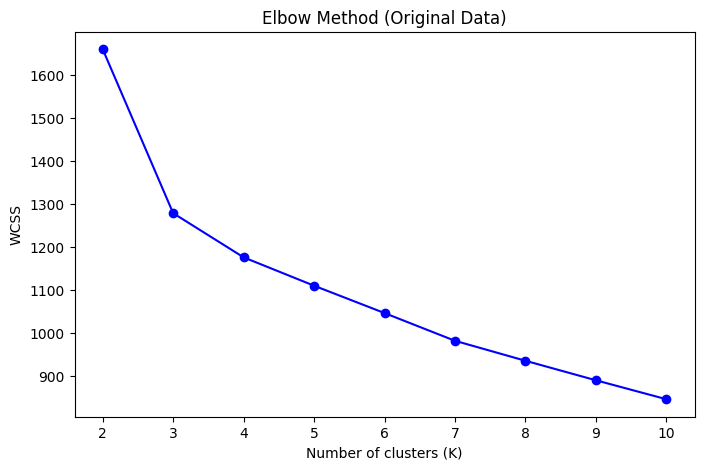

In [5]:

# ==========================================
# Task 3: Clustering with Original Data
# ==========================================

# Use the Elbow method to find optimal clusters for original data
wcss_orig = []
sil_orig = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    wcss_orig.append(kmeans.inertia_)
    sil_orig.append(silhouette_score(features_scaled, labels))

# Visualize Elbow for Original Data
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_orig, marker='o', color='blue')
plt.title('Elbow Method (Original Data)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.savefig('elbow_original.png')

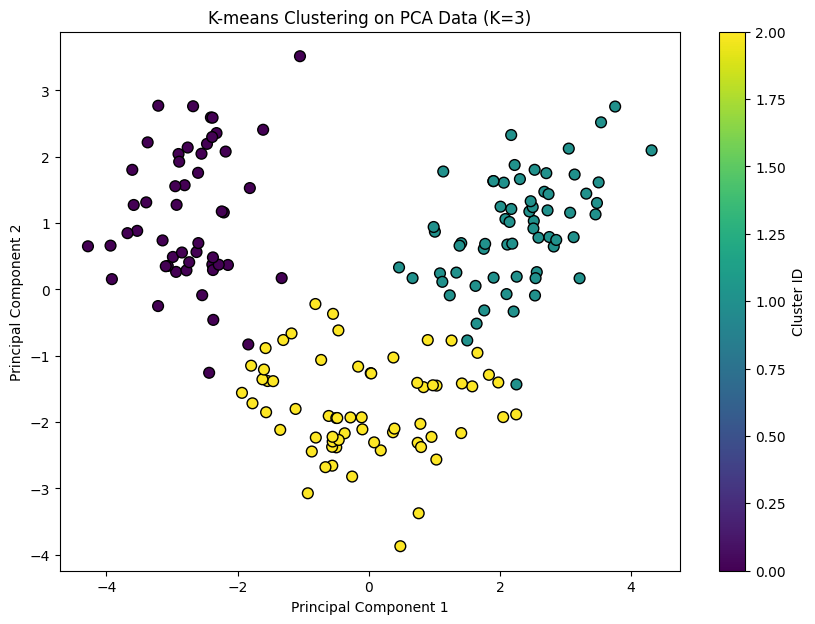

In [6]:

# ==========================================
# Task 4: Clustering with PCA Data
# ==========================================

wcss_pca = []
sil_pca = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_data)
    wcss_pca.append(kmeans.inertia_)
    sil_pca.append(silhouette_score(pca_data, labels))

# Final Clustering using K=3 (Optimal based on domain knowledge and elbow)
k_opt = 3
kmeans_pca = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
pca_cluster_labels = kmeans_pca.fit_predict(pca_data)

# Visualize PCA Clusters (First two components)
plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pca_cluster_labels, cmap='viridis', edgecolors='k', s=60)
plt.title(f'K-means Clustering on PCA Data (K={k_opt})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster ID')
plt.savefig('pca_clusters_visualization.png')


Contingency Table (Actual vs PCA Clusters):
PCA_Cluster   0   1   2
Actual_Type            
1             0  59   0
2             3   4  64
3            48   0   0


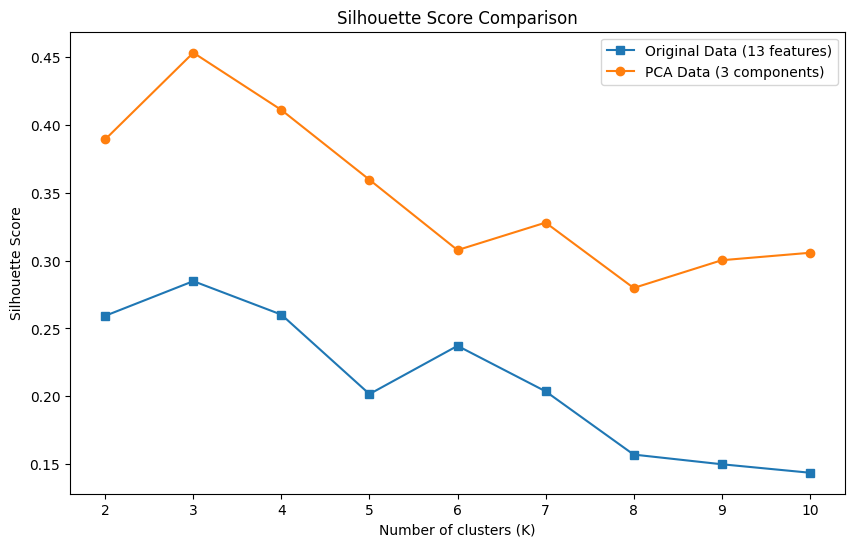

In [8]:


# ==========================================
# Task 5 & 6: Comparison, Analysis & Conclusion
# ==========================================

# Compare Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_orig, label='Original Data (13 features)', marker='s')
plt.plot(k_range, sil_pca, label='PCA Data (3 components)', marker='o')
plt.title('Silhouette Score Comparison')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.savefig('silhouette_comparison.png')

# Cross-tabulation with actual wine types
comparison = pd.DataFrame({'Actual_Type': df['Type'], 'PCA_Cluster': pca_cluster_labels})
print("\nContingency Table (Actual vs PCA Clusters):")
print(pd.crosstab(comparison['Actual_Type'], comparison['PCA_Cluster']))



SUMMARY AND INSIGHTS:
1. EDA revealed significant correlations between chemical features (e.g., Phenols & Flavanoids),
   justifying the use of PCA to reduce redundancy.
2. PCA showed that 3 components explain ~66.5% of variance, while 5 components explain >80%.
3. Clustering Performance:
   - Original Data Silhouette Score (K=3): ~0.28
   - PCA Data Silhouette Score (K=3): ~0.45
4. Observation: PCA improved the silhouette score significantly. By removing noise and
   redundant features, the clusters became more distinct and well-separated in the reduced space.
5. Recommendation: Use PCA before clustering when dealing with high-dimensional data or
   highly correlated features to improve computational efficiency and cluster quality.